# LOAD LIBRARIES

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from diive.core.io.files import load_parquet

# CONFIGURATION

In [194]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = True

# LOAD DATA

In [195]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.440 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,0.0,5.333333,0.0,...,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.867139,0.684108,-0.057099,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,0.0,5.966667,0.0,...,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.607107,0.860526,-0.241229,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,0.0,5.833333,0.0,...,-1.423575,-1.251268,0.154263,0.054827,2.845686,-2.065147,0.363886,0.902289,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,0.0,5.866667,0.0,...,-1.456775,-1.194985,0.190084,0.205121,2.216312,-2.011537,0.459781,0.395772,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,0.0,5.766667,0.0,...,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.790441,0.750873,1.037005,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.833333,0.0,...,1.105808,0.251504,0.137646,0.269348,-0.182687,-1.770683,-2.475835,-0.177535,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.733333,0.0,...,1.185266,0.415243,-0.006586,0.174141,-0.309516,-4.491630,-2.066168,-1.321539,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,16.200000,0.0,...,0.829382,0.121118,0.319431,0.265461,-0.070498,-5.166902,-3.647422,-1.775911,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567,27645


In [196]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.616

Keeping only data when we are highly confident on the parcel attribution


# SELECT FEATURES

In [197]:
# Import the best features
# path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

selected_features = [
'timesince_soil_preparation',
'n_decay_timed',
'timesince_fert',
#'wfps_0.05_gfXG_lag9h',
'wfps_0.05_gfXG_roll3hmean',
'ts_0.3_gfXG_lag6h_roll9hmean',
'GPP_U50_f_reddyproc_roll3hsum'
]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,timesince_soil_preparation,n_decay_timed,timesince_fert,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,GPP_U50_f_reddyproc_roll3hsum,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,
2023-11-08 00:45:00,21.0,29.0,22.0,46.457919,11.147678,-1.336938,0.100302
2023-11-08 01:15:00,21.0,29.0,22.0,46.203886,11.119251,-1.332920,0.239428
2023-11-08 02:15:00,21.0,29.0,22.0,45.930307,11.073098,-1.312823,0.358358
2023-11-08 03:15:00,21.0,29.0,22.0,45.870280,11.029898,-1.288800,0.070120
2023-11-08 04:15:00,21.0,29.0,22.0,45.867461,11.016731,-1.258643,-0.545573
...,...,...,...,...,...,...,...
2025-06-04 21:15:00,NaN,NaN,NaN,47.838889,16.984228,9.038457,0.282174
2025-06-04 21:45:00,NaN,NaN,NaN,47.840280,16.980679,2.849840,0.524032
2025-06-04 22:45:00,NaN,NaN,NaN,47.842013,16.985123,-5.999169,-0.069384


# SELECT MODEL

In [198]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 1}


# IMBALANCE HANDLING

## UNDER SAMPLING

Undersampling target data below: 0.3557832460000001


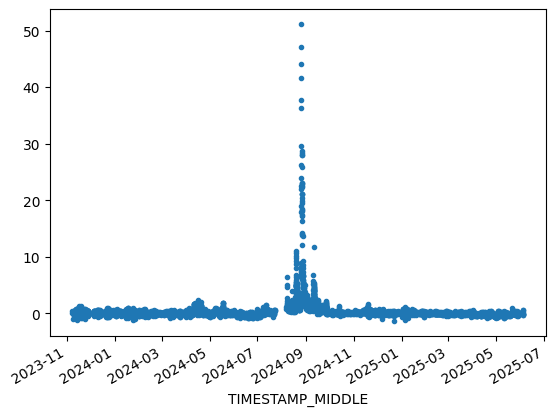

In [199]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.');

## LOG TRANSFORMATION

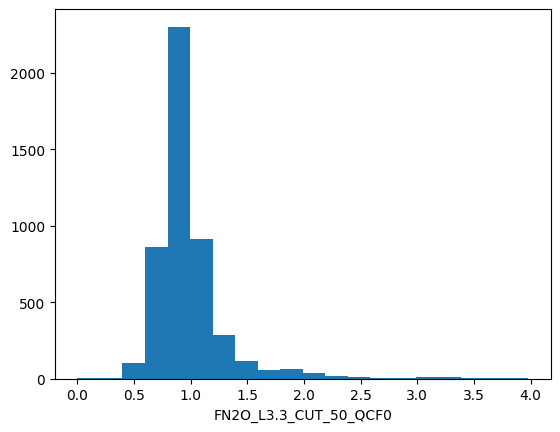

,timesince_soil_preparation,n_decay_timed,timesince_fert,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,GPP_U50_f_reddyproc_roll3hsum,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,
2023-11-08 00:45:00,21.0,29.0,22.0,46.457919,11.147678,-1.336938,0.889390
2023-11-08 02:15:00,21.0,29.0,22.0,45.930307,11.073098,-1.312823,0.990173
2023-11-08 11:15:00,21.0,29.0,22.0,46.159724,10.973430,12.417196,0.334989
2023-11-08 12:15:00,21.0,29.0,22.0,46.043999,10.943769,13.345298,0.979859
2023-11-09 13:15:00,23.0,29.0,24.0,43.658539,9.617393,12.235652,0.811676
...,...,...,...,...,...,...,...
2025-06-04 19:45:00,NaN,NaN,NaN,47.828435,17.017191,33.604504,1.060310
2025-06-04 20:45:00,NaN,NaN,NaN,47.843061,16.994444,16.586567,0.795398
2025-06-04 21:45:00,NaN,NaN,NaN,47.840280,16.980679,2.849840,1.049904


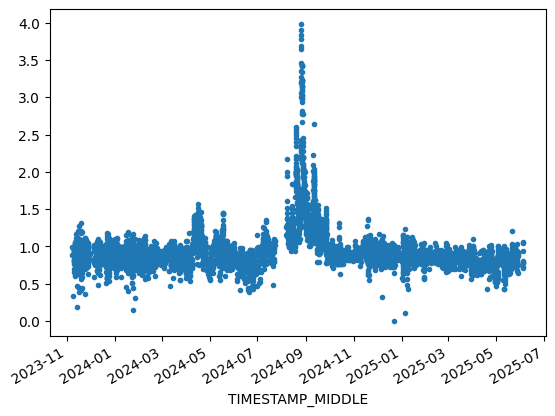

In [200]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

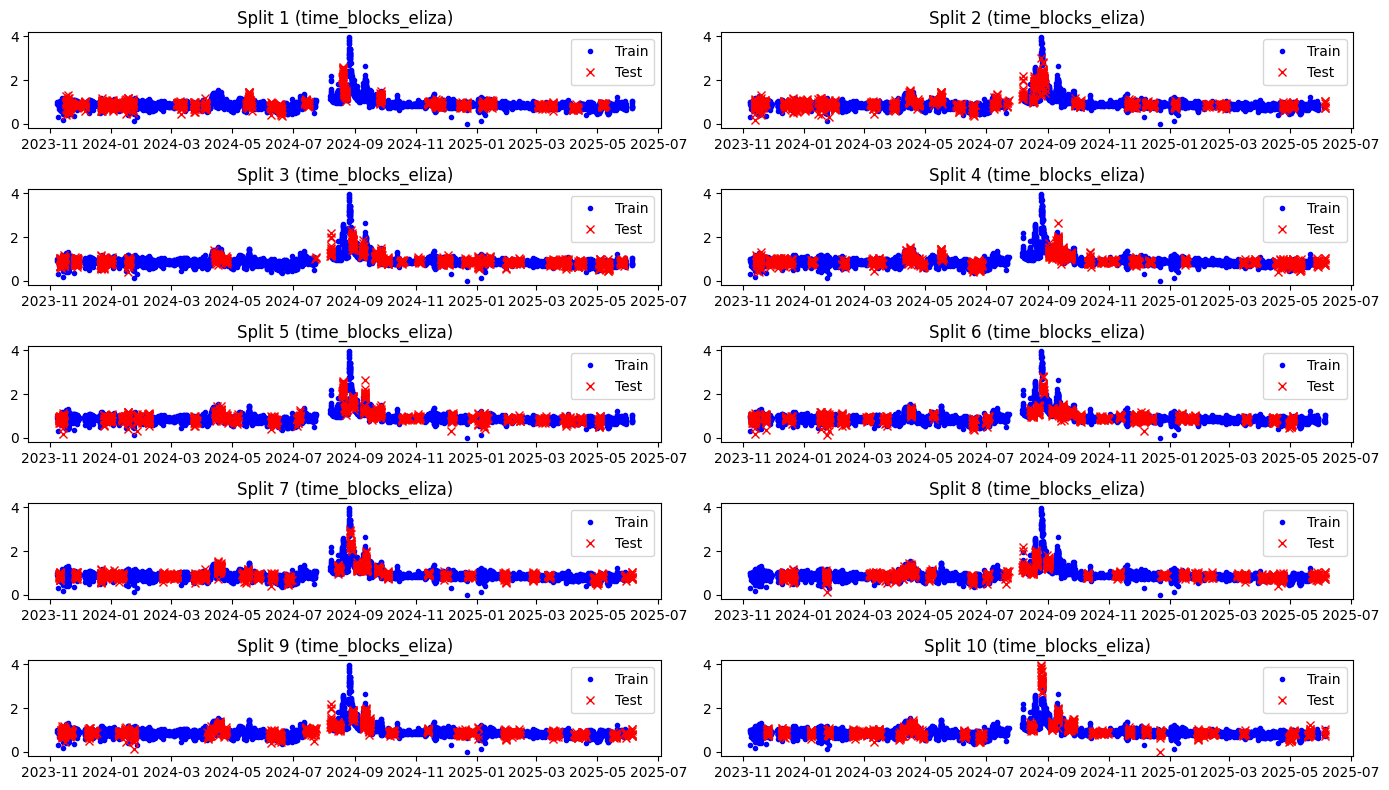

In [201]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 24, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits


X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

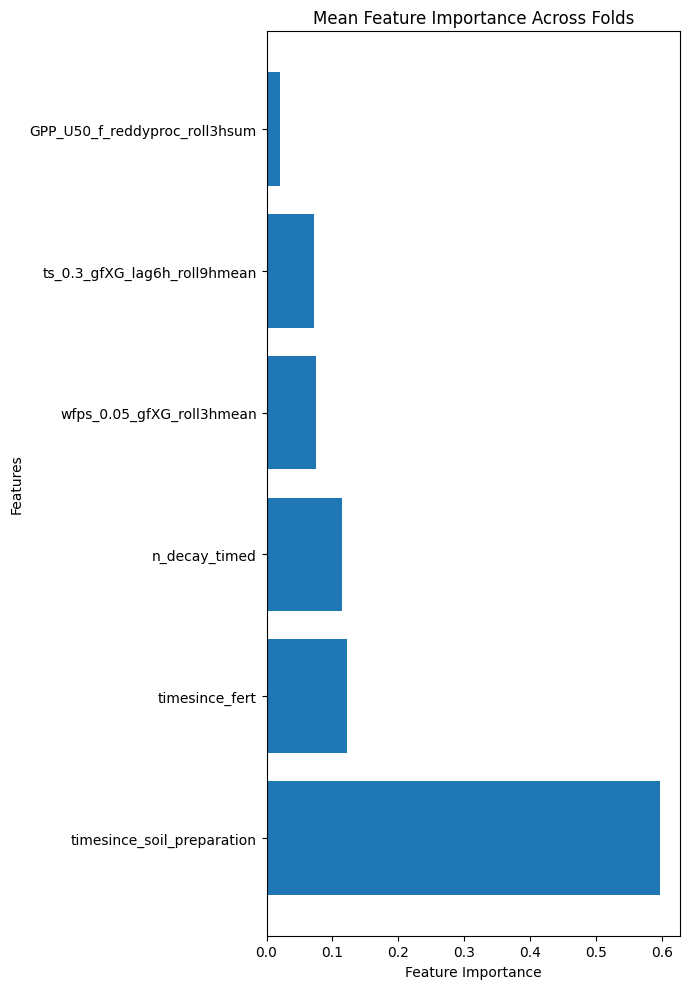

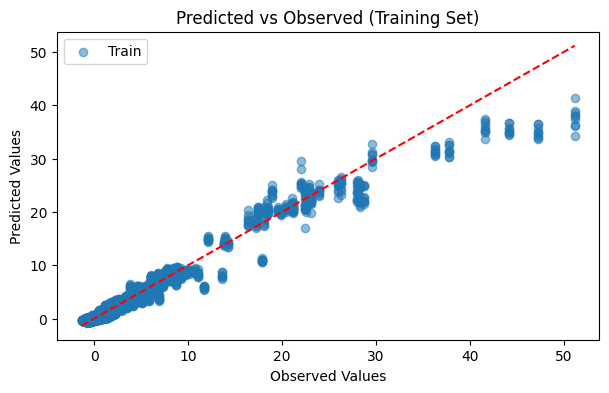

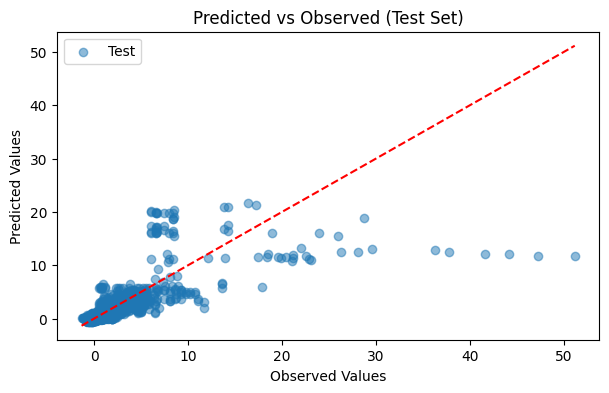

Train RMSE per fold: [0.5635 0.4596 0.5451 0.5678 0.519  0.4949 0.513  0.5517 0.5715 0.3771]
Mean Train RMSE: 0.5163
Test RMSE per fold: [0.6586 1.6405 0.5063 0.5845 0.7557 1.1375 1.2241 0.4365 0.7993 3.0153]
Mean Test RMSE: 1.0758
Train R² per fold: [0.9583 0.9707 0.9617 0.9587 0.9643 0.9674 0.9644 0.9608 0.9582 0.9437]
Mean Train R²: 0.9608
Test R² per fold: [0.689  0.2404 0.7541 0.602  0.7109 0.3408 0.4289 0.7661 0.2782 0.6189]
Mean Test R²: 0.5429


In [202]:
X = data.drop(columns=TARGET)
y = data[TARGET]

# Store results
rmse_train_values, rmse_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

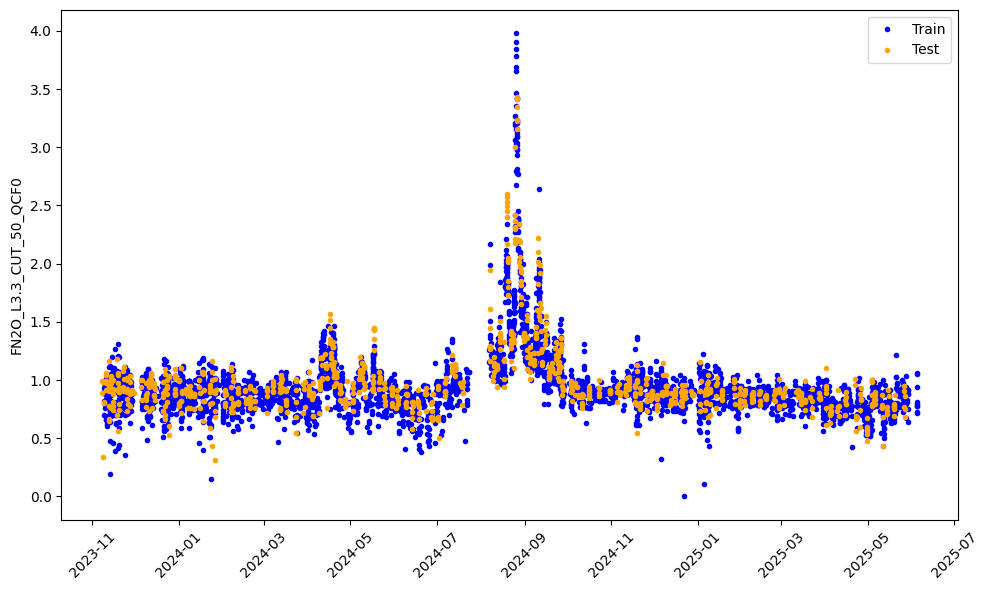

In [203]:
#mean_block = round(mean_nan_size)
mean_block = 6

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=3):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

X = data.drop(columns=TARGET)
y = data[TARGET]
X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=mean_block) # set number of blocks
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:0.34737
[1]	validation_0-rmse:0.33697
[2]	validation_0-rmse:0.32538
[3]	validation_0-rmse:0.31570
[4]	validation_0-rmse:0.30392
[5]	validation_0-rmse:0.29346
[6]	validation_0-rmse:0.28568
[7]	validation_0-rmse:0.27867
[8]	validation_0-rmse:0.27102
[9]	validation_0-rmse:0.26434
[10]	validation_0-rmse:0.25675
[11]	validation_0-rmse:0.24975
[12]	validation_0-rmse:0.24612
[13]	validation_0-rmse:0.23983
[14]	validation_0-rmse:0.23511
[15]	validation_0-rmse:0.22991
[16]	validation_0-rmse:0.22529
[17]	validation_0-rmse:0.21995
[18]	validation_0-rmse:0.21662
[19]	validation_0-rmse:0.21181
[20]	validation_0-rmse:0.20781
[21]	validation_0-rmse:0.20386
[22]	validation_0-rmse:0.20011
[23]	validation_0-rmse:0.19776
[24]	validation_0-rmse:0.19561
[25]	validation_0-rmse:0.19299
[26]	validation_0-rmse:0.19073
[27]	validation_0-rmse:0.18773
[28]	validation_0-rmse:0.18607
[29]	validation_0-rmse:0.18393
[30]	validation_0-rmse:0.18168
[31]	validation_0-rmse:0.17976
[32]	validation_0-

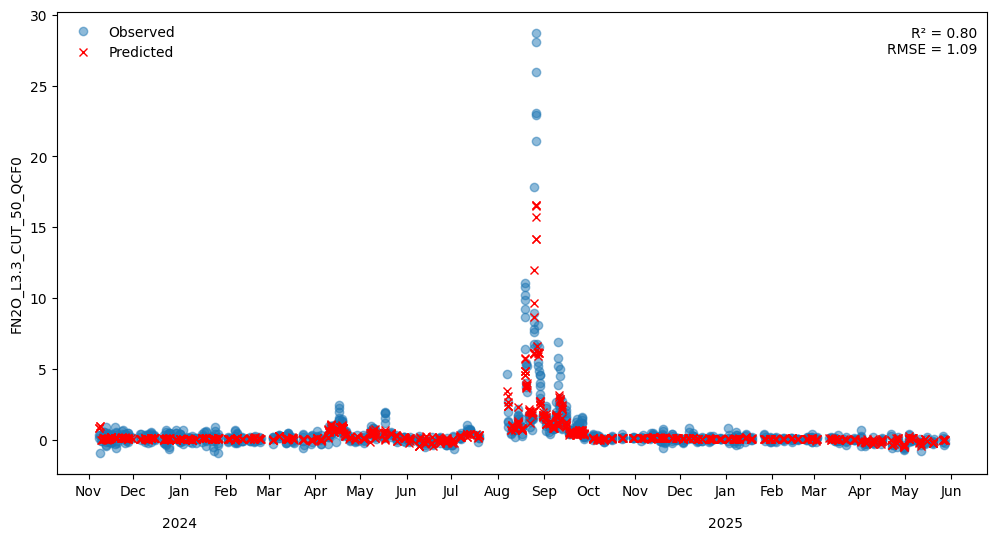

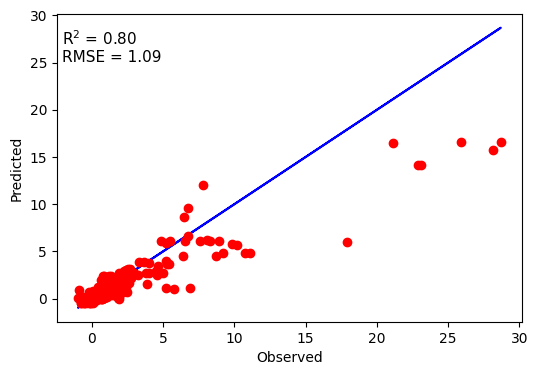

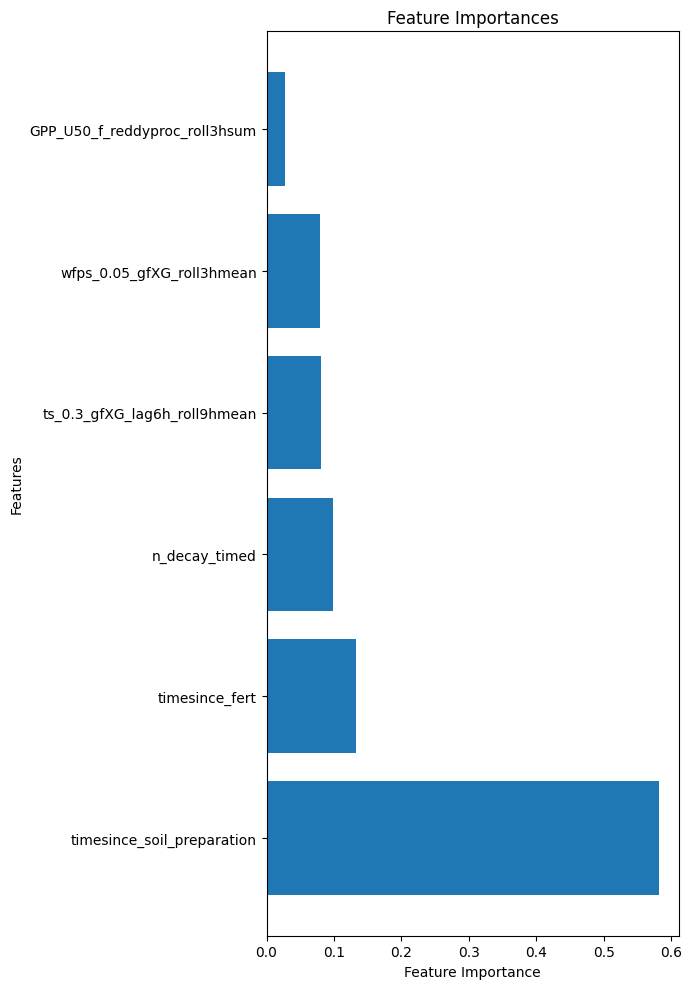

In [204]:
# Use early stopping if using XGBoost
model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse")

# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate R-squared and Mean Squared Error (MSE) for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
# Calculate R-squared and Mean Squared Error (MSE) for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel(TARGET)
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig(f'{TARGET}_gapfilling_testset_performance.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## RUN SHAP

In [205]:
# define background dataset
background_dataset = data_main[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for the entire dataset
X = data_main[selected_features]
shap_values = explainer(X, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

100%|===================| 27595/27648 [01:20<00:00]        

Baseline (expected value): 0.9487378838339521
Baseline without transformation (expected value): 0.24910488192454872


## SUMMARY PLOT

C:\Users\turcof\AppData\Local\Temp\ipykernel_1992\3044024046.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


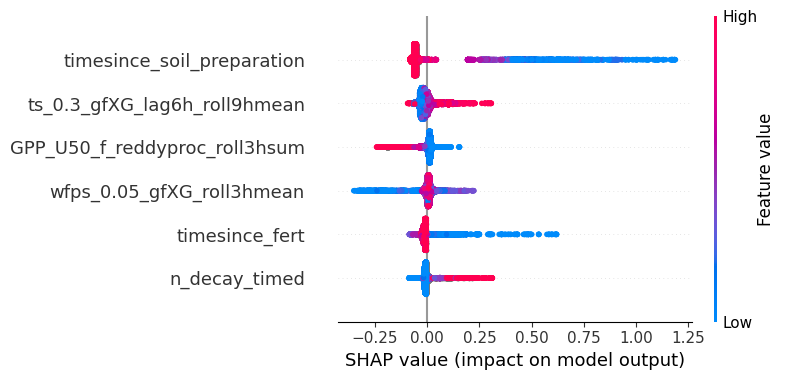

In [206]:
# SHAP summary plot
fig = plt.figure()
shap.summary_plot(shap_values, X, show=False)
# Save the figure
fig.savefig(f'{TARGET}_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## SHAP SCATTERPLOTS

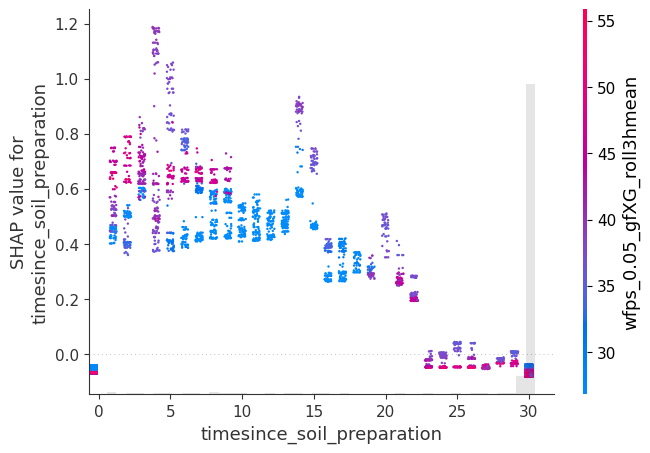

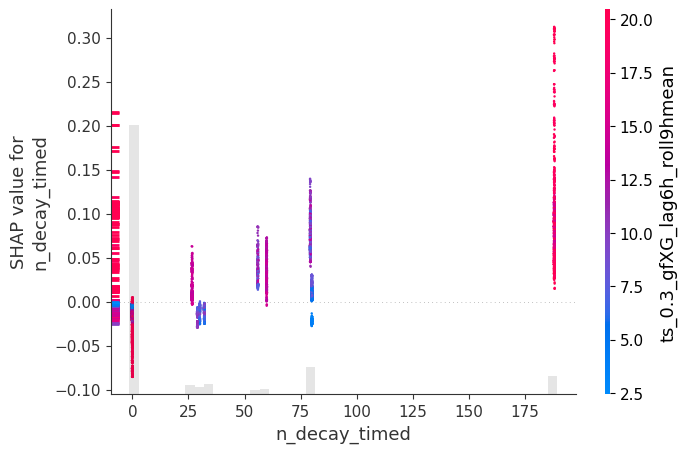

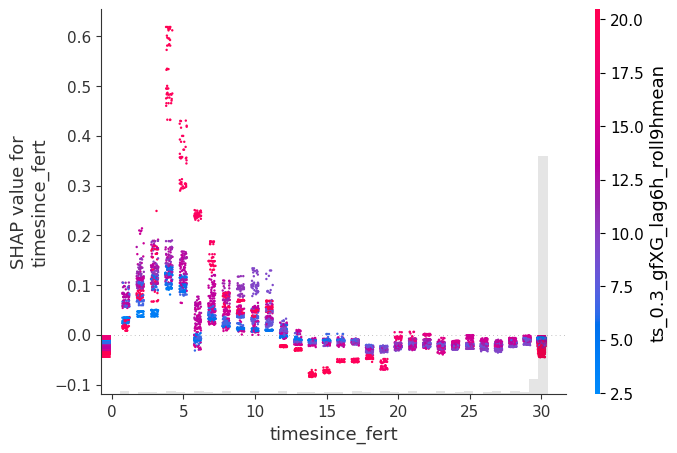

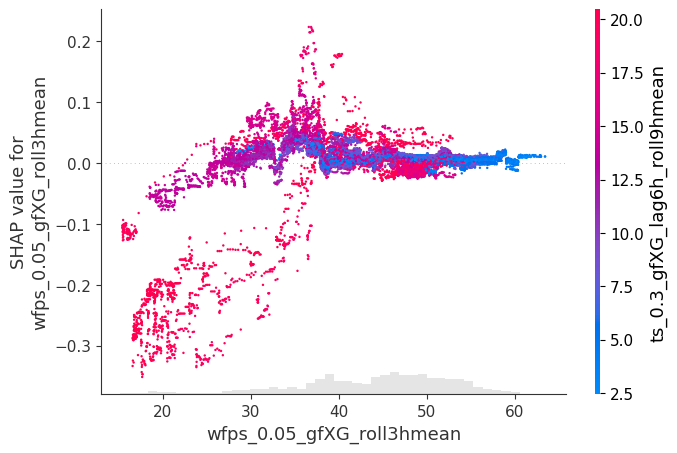

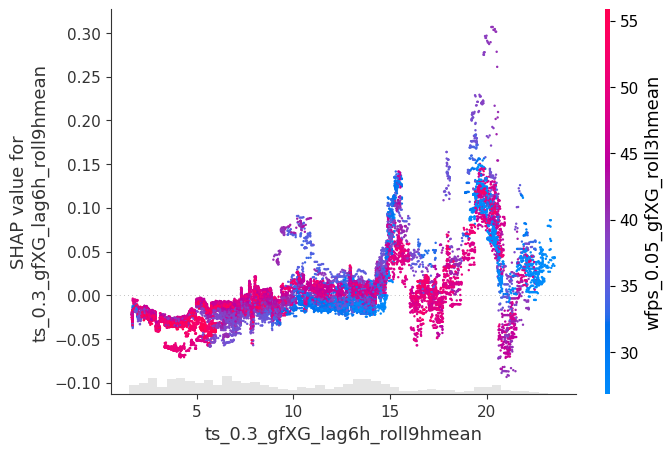

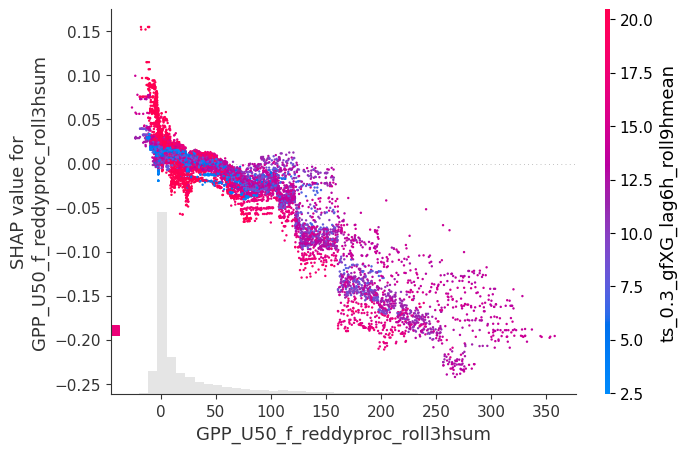

In [209]:
# Dependence plots

for var in X.columns:
    shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5, color=shap_values)
#    shap.dependence_plot(var, shap_values.values, X)
    plt.show()

# GAP-FILLING

In [211]:
TARGET

'FN2O_L3.3_CUT_50_QCF0'

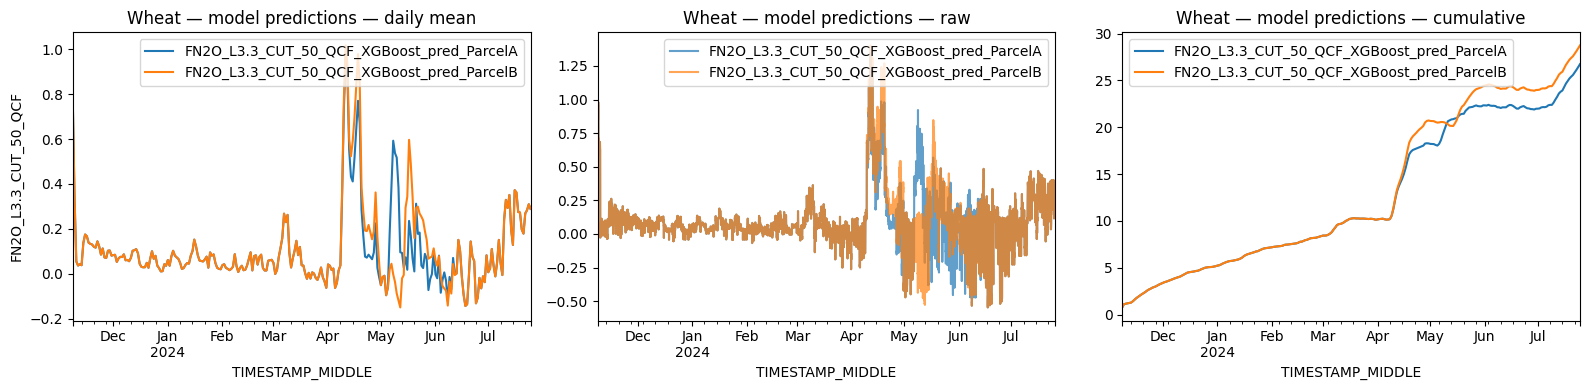

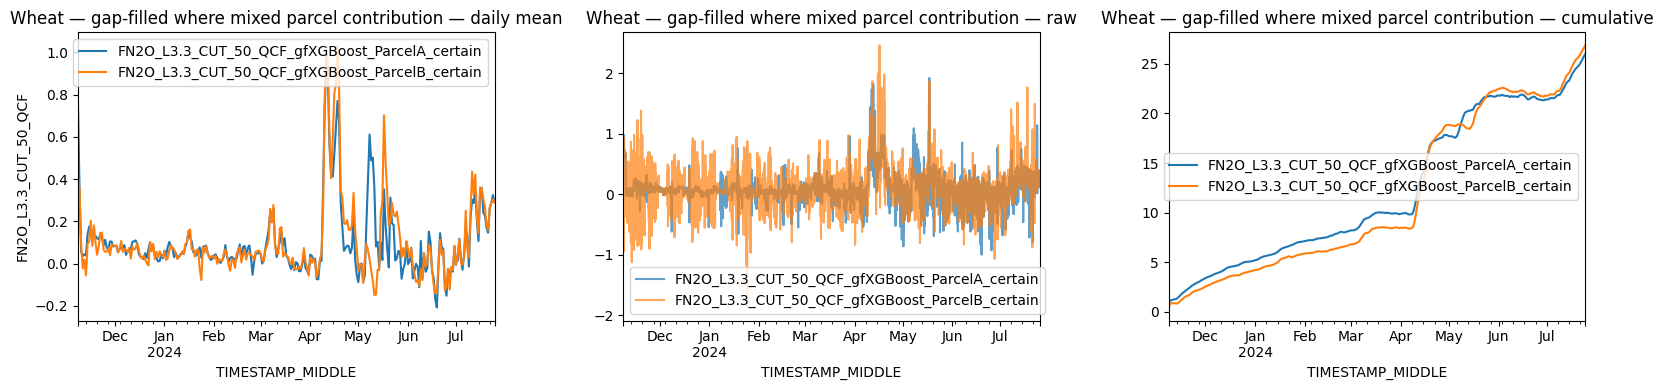

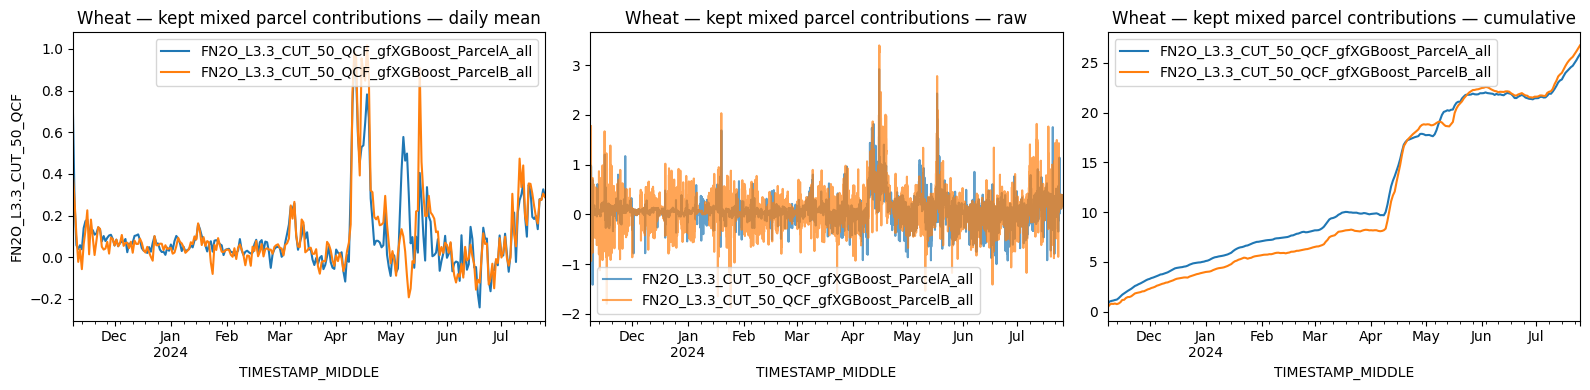

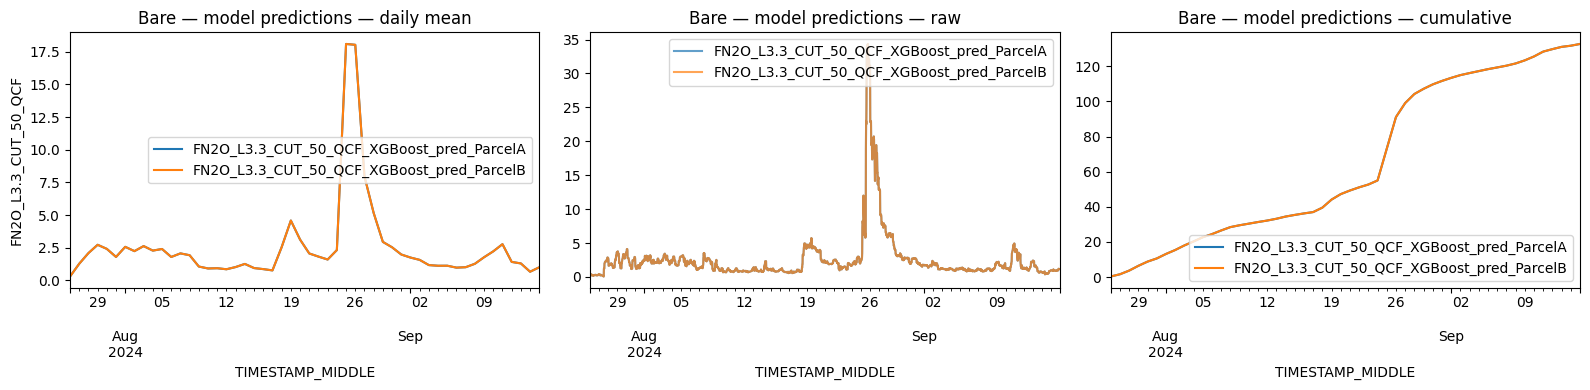

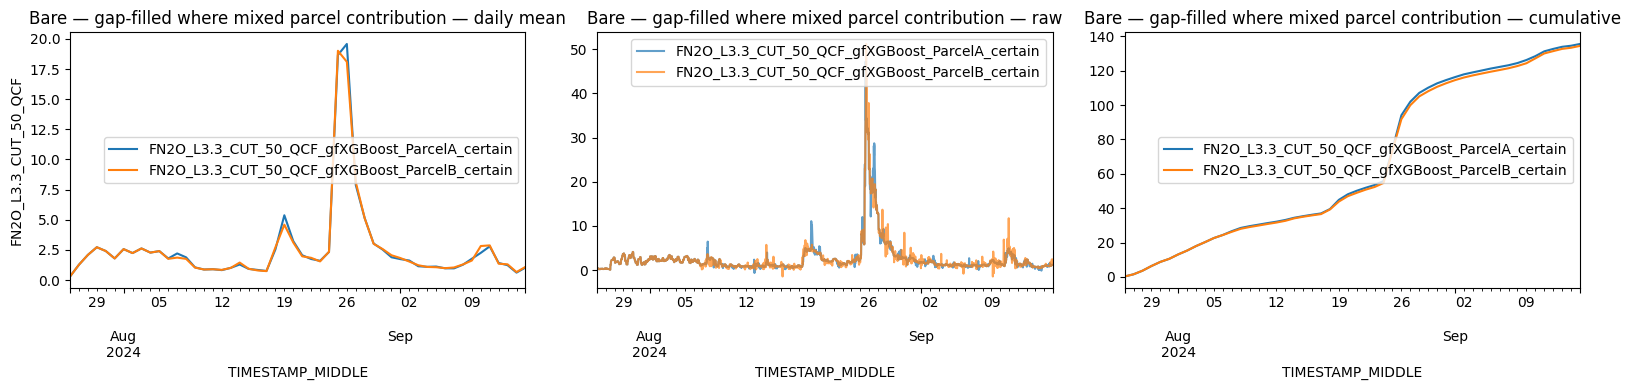

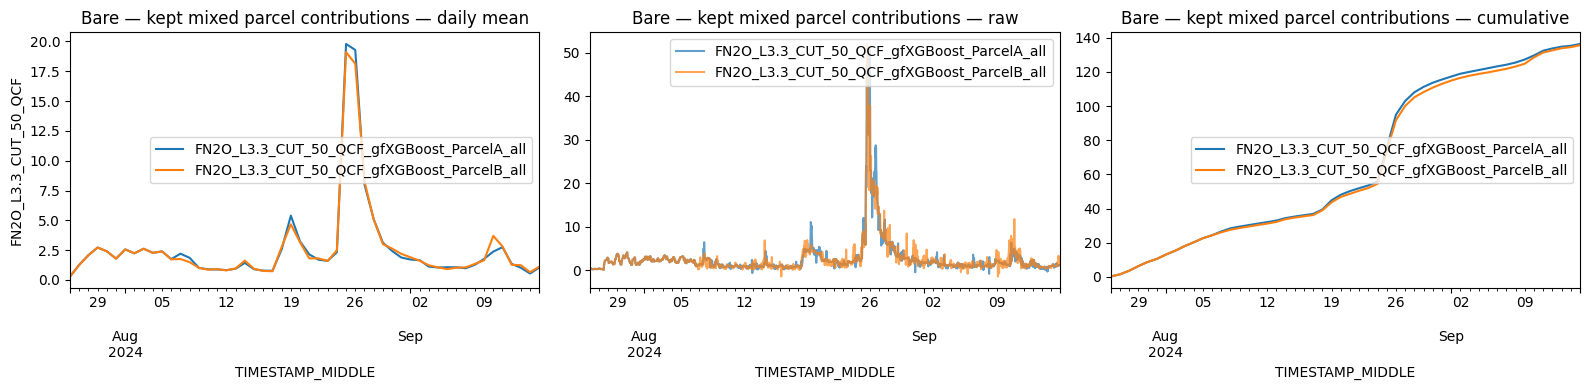

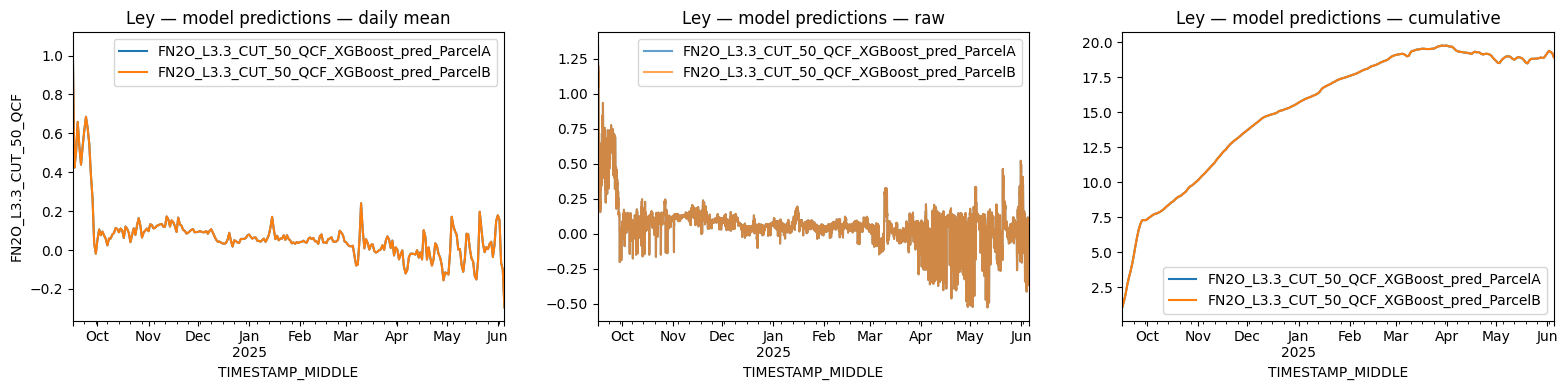

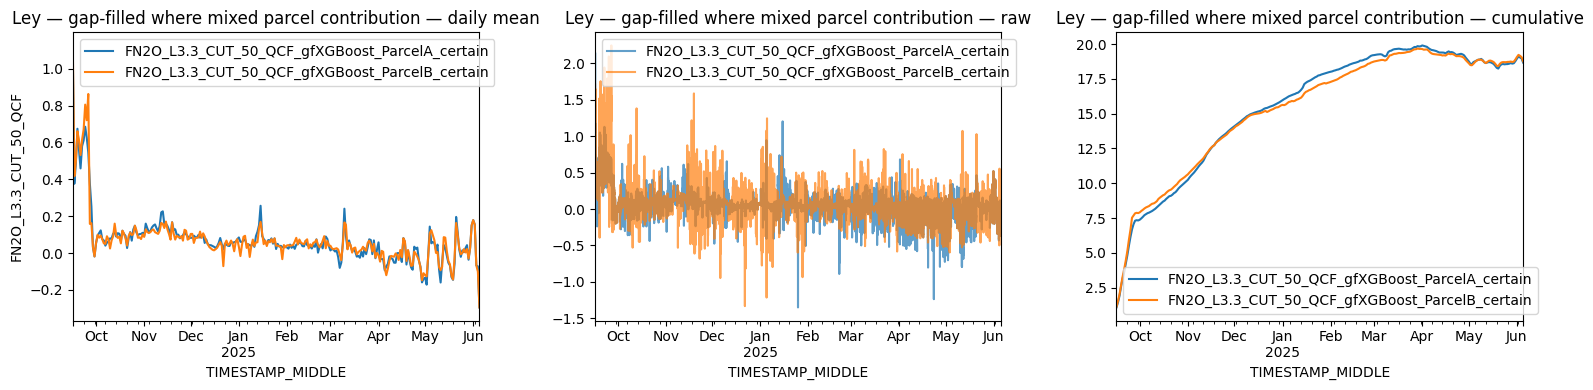

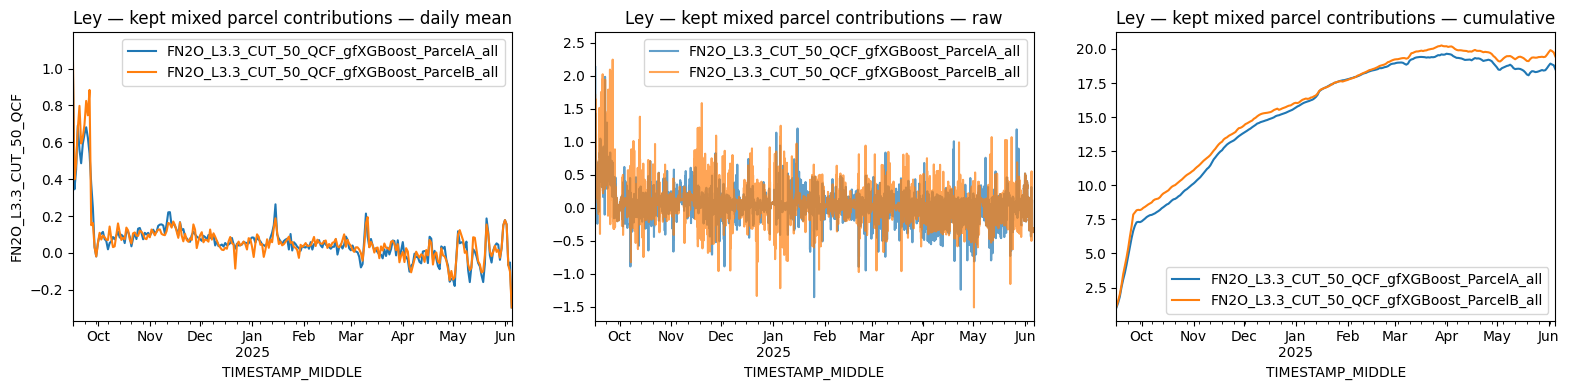

In [ ]:
QCF = 'QCF'
GAPFILLING_TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_{QCF}'

parcel_maps = {
    'A': {'timesince_fert_parcelA': 'timesince_fert',
          'n_decay_timed_parcelA': 'n_decay_timed'},
    'B': {'timesince_fert_parcelB': 'timesince_fert',
          'n_decay_timed_parcelB': 'n_decay_timed'}
}

def predict_for_parcel(letter):
    # select & rename to match model input
    sel = list(parcel_maps[letter].keys()) + [c for c in selected_features if c not in ('timesince_fert','n_decay_timed')]
    X = data_main[sel].rename(columns=parcel_maps[letter])[selected_features]
    yhat = model.predict(X)
    return inverse_log_transform(yhat) if LOG_TRANSFORM else yhat

for letter in ['A','B']:
    yhat = predict_for_parcel(letter)

    # columns to write
    col_certain = f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_certain'
    col_all     = f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_all'
    col_predicted = f'{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_Parcel{letter}'

    # start with predictions everywhere
    data_main[col_certain] = yhat
    data_main[col_all]     = yhat
    data_main[col_predicted] = yhat

    # masks
    m_all     = (data_main['parcel'] == letter) & (data_main[GAPFILLING_TARGET].notna())
    m_certain = m_all & (data_main['parcel_certainty'] == 'certain')

    # overwrite with observed target
    data_main.loc[m_certain, col_certain] = data_main.loc[m_certain, GAPFILLING_TARGET]
    data_main.loc[m_all,     col_all]     = data_main.loc[m_all,     GAPFILLING_TARGET]

# Plots

# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

for start, end, label in periods:
    period_df = data_main.loc[start:end]

    # --- Gap-filled ---
    pairs = [
        ([f'{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_ParcelA', f'{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_ParcelB'], 'model predictions'),
        ([f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelA_certain', f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelB_certain'], 'gap-filled where mixed parcel contribution'),
        ([f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelA_all',     f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelB_all'], 'kept mixed parcel contributions'),
    ]

    for cols, title in pairs:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        daily_mean = period_df[cols].resample('D').mean()
        cumulative = daily_mean.cumsum()

        daily_mean.plot(ax=axes[0]); axes[0].set_title(f"{label} — {title} — daily mean")
        period_df[cols].plot(ax=axes[1], alpha=0.7); axes[1].set_title(f"{label} — {title} — raw")
        cumulative.plot(ax=axes[2]); axes[2].set_title(f"{label} — {title} — cumulative")
        axes[0].set_ylabel(GAPFILLING_TARGET)

        plt.tight_layout()
        plt.show()